# HAL-TMLE-RC v2 API Demo

This notebook is a pure demo of the package API for right-censored survival targeting v2.

The notebook only does:
- data generation;
- Stage 1 fit;
- API call to `right_censored_survival_targeting_M_step_v2`;
- compact result inspection and plots.

In [1]:
import os
import sys
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import truncnorm

ROOT = pathlib.Path.cwd().resolve()
for candidate in [ROOT, ROOT.parent, ROOT.parent.parent]:
    src_path = candidate / 'src'
    if src_path.exists() and str(src_path) not in sys.path:
        sys.path.append(str(src_path))

os.environ.setdefault('MPLCONFIGDIR', str((ROOT / '.matplotlib').resolve()))

from haldensity.censoring.right.estimators import RightCensoredInitEstimator
from haldensity.censoring.right.km import KaplanMeier
from haldensity.censoring.right.weights import compute_ipcw_weights
from haldensity.censoring.tuners.right_tuners import RightCensoredInitTuner
from haldensity.targeting import right_censored_survival_targeting_M_step_v2

/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
RNG_SEED = 42
N = 200
CV_FOLDS = 5
N_TRIALS = 10
N_GRID_POINTS = 200
BASIS_ORDER_OPTIONS = [2]
GBAR_CLIP = 1e-6
SURVIVAL_CLIP = 1e-8
EPS_BRACKET_START = 0.25
EPS_BRACKET_GROWTH = 2.0
EPS_BRACKET_MAX = 16.0
EPS_FALLBACK_BOUNDS = (-1e6, 1e6)

MAX_ITER = 25
MIN_ABS_EPS = 1e-10
MIN_SCORE_TOL = 1e-15

TARGET_TIMES = np.linspace(0.001, 0.999, 10)
FOCUS_T0 = 0.85

np.random.seed(RNG_SEED)

In [3]:
event_mean = 0.5
event_std = 0.15
lower, upper = 0.0, 1.0
a = (lower - event_mean) / event_std
b = (upper - event_mean) / event_std
event_times = truncnorm.rvs(a, b, loc=event_mean, scale=event_std, size=N)
censor_times = np.random.uniform(0.0, 1.0, size=N)
tilde_T = np.minimum(event_times, censor_times)
Delta = (event_times <= censor_times).astype(int)
data = pd.DataFrame({'T': tilde_T, 'Delta': Delta})

print(f'n={N}, uncensored={Delta.sum()}, censored={N - Delta.sum()}')
print(f'censoring rate: {1 - Delta.mean():.1%}')

data.head()

n=200, uncensored=103, censored=97
censoring rate: 48.5%


,T,Delta
0,0.452065,1
1,0.084140,0
2,0.161629,0
3,0.537449,1
4,0.348541,1


In [4]:
init_tuner = RightCensoredInitTuner(
    data=data,
    cv_folds=CV_FOLDS,
    n_grid_points=N_GRID_POINTS,
    silent=True,
)
init_tuner.param_overrides = {'basis_order': BASIS_ORDER_OPTIONS}
tuned_init = init_tuner.optimize(n_trials=N_TRIALS)

km_shared = KaplanMeier().fit(data, time_col='T', delta_col='Delta')
shared_weights = compute_ipcw_weights(
    T=data['T'].to_numpy(),
    Delta=data['Delta'].to_numpy(),
    S_c_predict=lambda t: np.atleast_1d(km_shared.predict(t)),
    clip=GBAR_CLIP,
)
uncensored_mask = data['Delta'].to_numpy() == 1
uncensored_df = pd.DataFrame({'W1': data.loc[uncensored_mask, 'T'].to_numpy()})

stage1_estimator = RightCensoredInitEstimator(
    tol=tuned_init.estimator.tol,
    norm_constraint=float(tuned_init.best_params['norm_constraint']),
    n_grid_points=N_GRID_POINTS,
    basis_order=int(tuned_init.best_params['basis_order']),
    solver=tuned_init.estimator.solver,
    use_secondary_solver=tuned_init.estimator.use_secondary_solver,
)
stage1_estimator.fit(uncensored_df, sample_weights=shared_weights[uncensored_mask])

print('Stage 1 tuning best params:', tuned_init.best_params)
print('Stage 1 selected knots:', int(stage1_estimator.get_results()['n_selected_knots']))
print('KM reused across Stage 1 and targeting:', isinstance(km_shared, KaplanMeier))
print('Tuner has Optuna study history:', 'study' in tuned_init.metadata)

Stage 1 tuning best params: {'norm_constraint': 42.810527937199474, 'basis_order': 2}
Stage 1 selected knots: 23
KM reused across Stage 1 and targeting: True
Tuner has Optuna study history: True


In [5]:
# API demo notebook: implementation lives in package `haldensity.targeting`.

In [6]:
# Demo uses the package API directly (no in-notebook implementation).
pass

In [7]:
v2_fit = right_censored_survival_targeting_M_step_v2(
    initial_estimator=stage1_estimator,
    observed_data=data,
    targeting_points=TARGET_TIMES,
    km=km_shared,
    mode='iterative',
    clip=GBAR_CLIP,
    survival_clip=SURVIVAL_CLIP,
    eps_bracket_start=EPS_BRACKET_START,
    eps_bracket_growth=EPS_BRACKET_GROWTH,
    eps_bracket_max=EPS_BRACKET_MAX,
    eps_fallback_bounds=EPS_FALLBACK_BOUNDS,
    max_iter=MAX_ITER,
    min_abs_eps=MIN_ABS_EPS,
    min_score_tol=MIN_SCORE_TOL,
    store_pointwise_arrays=True,
)

summary_v2 = v2_fit['summary']
summary_v2[[
    't0',
    'psi_init',
    'psi_one_step',
    'psi_final',
    'eif_mean_one_step',
    'eif_mean_final',
    'sigma_over_sqrtnlogn_one_step',
    'threshold_one_step',
    'threshold_final',
    'continued_past_one_step',
    'n_iterations',
    'stop_reason',
]]


,t0,psi_init,psi_one_step,psi_final,eif_mean_one_step,eif_mean_final,sigma_over_sqrtnlogn_one_step,threshold_one_step,threshold_final,continued_past_one_step,n_iterations,stop_reason
0,0.001000,0.999974,1.000000e+00,1.000000e+00,1.000000e-303,1.000000e-303,0.000000e+00,1.000000e-15,1.000000e-15,False,1,score_tolerance
1,0.111889,0.993597,1.000000e+00,1.000000e+00,1.118379e-301,1.118379e-301,0.000000e+00,1.000000e-15,1.000000e-15,False,1,score_tolerance
2,0.222778,0.966619,9.753668e-01,9.753668e-01,-2.778941e-06,-2.778941e-06,2.303973e-03,2.303973e-03,2.303973e-03,False,1,score_tolerance
3,0.333667,0.864957,8.784424e-01,8.784424e-01,-8.797000e-06,-8.797000e-06,5.099993e-03,5.099993e-03,5.099993e-03,False,1,score_tolerance
4,0.444556,0.631282,5.965070e-01,5.965070e-01,2.031091e-04,2.031091e-04,8.236175e-03,8.236175e-03,8.236175e-03,False,1,score_tolerance
5,0.555444,0.326559,3.319267e-01,3.319267e-01,-1.702617e-05,-1.702617e-05,8.521578e-03,8.521578e-03,8.521578e-03,False,1,score_tolerance
6,0.666333,0.103179,1.255580e-01,1.255580e-01,-2.538741e-04,-2.538741e-04,6.836852e-03,6.836852e-03,6.836852e-03,False,1,score_tolerance
7,0.777222,0.017853,7.392316e-04,4.077864e-10,-7.293353e-04,-3.344067e-17,4.234561e-05,4.234561e-05,5.214003e-10,True,6,score_tolerance
8,0.888111,0.001553,1.018721e-08,3.075866e-305,-1.009971e-08,-2.327548e-12,5.965803e-10,5.965803e-10,5.539083e-10,True,2,score_tolerance
9,0.999000,0.000002,2.750684e-307,2.750684e-307,-2.510520e-11,-2.510520e-11,5.544958e-10,5.544958e-10,5.544958e-10,False,1,score_tolerance


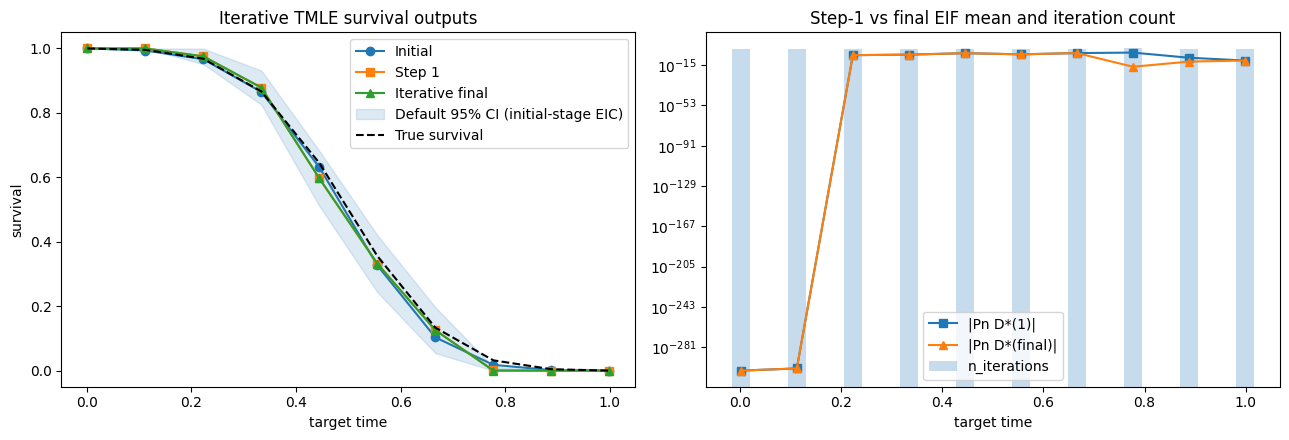

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

true_survival = truncnorm.sf(
    summary_v2['t0'].to_numpy(dtype=float),
    a,
    b,
    loc=event_mean,
    scale=event_std,
)

axes[0].plot(summary_v2['t0'], summary_v2['psi_init'], marker='o', label='Initial')
axes[0].plot(summary_v2['t0'], summary_v2['psi_one_step'], marker='s', label='Step 1')
axes[0].plot(summary_v2['t0'], summary_v2['psi_final'], marker='^', label='Iterative final')
axes[0].fill_between(
    summary_v2['t0'],
    summary_v2['ci_lower'],
    summary_v2['ci_upper'],
    color='tab:blue',
    alpha=0.15,
    label='Default 95% CI (initial-stage EIC)',
)
axes[0].plot(summary_v2['t0'], true_survival, linestyle='--', color='black', label='True survival')
axes[0].set_title('Iterative TMLE survival outputs')
axes[0].set_xlabel('target time')
axes[0].set_ylabel('survival')
axes[0].legend()

axes[1].plot(summary_v2['t0'], np.abs(summary_v2['eif_mean_one_step']), marker='s', label='|Pn D*(1)|')
axes[1].plot(summary_v2['t0'], np.abs(summary_v2['eif_mean_final']), marker='^', label='|Pn D*(final)|')
axes[1].bar(summary_v2['t0'], summary_v2['n_iterations'], width=0.035, alpha=0.25, label='n_iterations')
axes[1].set_yscale('log')
axes[1].set_title('Step-1 vs final EIF mean and iteration count')
axes[1].set_xlabel('target time')
axes[1].legend()

plt.tight_layout()
plt.show()

In [10]:
summary_v2[
    [
        't0',
        'continued_past_one_step',
        'eif_mean_one_step',
        'sigma_over_sqrtnlogn_one_step',
        'threshold_one_step',
        'epsilon_one_step',
        'eif_mean_final',
        'sigma_over_sqrtnlogn_final',
        'threshold_final',
        'epsilon_last',
        'n_iterations',
        'stop_reason',
        'estimand_variance',
        'estimand_variance_one_step',
        'estimand_variance_final',
    ]
].sort_values('t0')

,t0,continued_past_one_step,eif_mean_one_step,sigma_over_sqrtnlogn_one_step,threshold_one_step,epsilon_one_step,eif_mean_final,sigma_over_sqrtnlogn_final,threshold_final,epsilon_last,n_iterations,stop_reason,estimand_variance,estimand_variance_one_step,estimand_variance_final
0,0.001000,False,1.000000e-303,0.000000e+00,1.000000e-15,154807.399005,1.000000e-303,0.000000e+00,1.000000e-15,154807.399005,1,score_tolerance,3.031379e-43,0.000000e+00,0.000000e+00
1,0.111889,False,1.118379e-301,0.000000e+00,1.000000e-15,381966.020506,1.118379e-301,0.000000e+00,1.000000e-15,381966.020506,1,score_tolerance,1.550176e-08,0.000000e+00,0.000000e+00
2,0.222778,False,-2.778941e-06,2.303973e-03,2.303973e-03,0.256141,-2.778941e-06,2.303973e-03,2.303973e-03,0.256141,1,score_tolerance,1.490611e-04,1.490153e-04,1.490153e-04
3,0.333667,False,-8.797000e-06,5.099993e-03,5.099993e-03,0.088767,-8.797000e-06,5.099993e-03,5.099993e-03,0.088767,1,score_tolerance,7.303821e-04,7.301550e-04,7.301550e-04
4,0.444556,False,2.031091e-04,8.236175e-03,8.236175e-03,-0.093370,2.031091e-04,8.236175e-03,8.236175e-03,-0.093370,1,score_tolerance,1.909263e-03,1.904264e-03,1.904264e-03
5,0.555444,False,-1.702617e-05,8.521578e-03,8.521578e-03,0.013290,-1.702617e-05,8.521578e-03,8.521578e-03,0.013290,1,score_tolerance,2.038650e-03,2.038525e-03,2.038525e-03
6,0.666333,False,-2.538741e-04,6.836852e-03,6.836852e-03,0.091132,-2.538741e-04,6.836852e-03,6.836852e-03,0.091132,1,score_tolerance,1.319174e-03,1.312165e-03,1.312165e-03
7,0.777222,True,-7.293353e-04,4.234561e-05,4.234561e-05,-0.853257,-3.344067e-17,5.214003e-10,5.214003e-10,-0.385693,6,score_tolerance,3.524128e-05,5.033763e-08,7.631651e-18
8,0.888111,True,-1.009971e-08,5.965803e-10,5.965803e-10,-2.880535,-2.327548e-12,5.539083e-10,5.539083e-10,-10240.152291,2,score_tolerance,2.665757e-07,9.991111e-18,8.612947e-18
9,0.999000,False,-2.510520e-11,5.544958e-10,5.544958e-10,-1628.464601,-2.510520e-11,5.544958e-10,5.544958e-10,-1628.464601,1,score_tolerance,5.737638e-13,8.631227e-18,8.631227e-18


## Notes

This notebook is an API usage demo.

The output keeps v1-style top-level keys while adding v2 diagnostics:
- `summary` includes one-step and final stage diagnostics;
- `pointwise_fits` include stage payloads and optional `iteration_history`;
- `mode='auto'` applies the one-step EIF gate to decide whether iterative targeting is used.